# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The model output is converted into a ranked action queue.
Each recommendation includes a reason code explaining why
a content item should be reviewed.

Reason codes:

- HIGH_DECAY:
  Content performance has declined compared with previous periods.

- LOW_CTR:
  Content receives impressions but users are not clicking enough.

- CONTENT_REFRESH:
  Existing content has potential value but needs updates.

- LOW_ENGAGEMENT:
  User interaction signals indicate improvement opportunities.

- HIGH_VALUE:
  Content already performs well and should be prioritized carefully.

In [5]:
# Check available variables
print([x for x in globals().keys() if not x.startswith("_")])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'open']


In [7]:
import os

for root, dirs, files in os.walk("../../work/outputs"):
    for file in files:
        print(os.path.join(root, file))

../../work/outputs\baseline_action_score.csv


In [8]:
import pandas as pd

queue = pd.read_csv("../../work/outputs/baseline_action_score.csv")

queue.head()

,content_id,baseline_score,reason_code,action_label
0,content_ef99c4abd9ab,0.922730,HIGH_SEARCH_VOLUME,REFRESH_CONTENT
1,content_454cc6654c6e,0.831635,HIGH_SEARCH_VOLUME,REFRESH_CONTENT
2,content_bf67a444faef,0.831635,HIGH_SEARCH_VOLUME,REFRESH_CONTENT
3,content_deb54e9e19cd,0.825635,HIGH_SEARCH_VOLUME,REFRESH_CONTENT
4,content_5ec29ae79c60,0.825635,HIGH_SEARCH_VOLUME,REFRESH_CONTENT


In [9]:
import os

print(os.listdir("../../work"))
print(os.listdir("../../work/outputs"))

['capstone_report_template.md', 'notebooks', 'outputs', 'README.md']
['baseline_action_score.csv']


In [10]:
import os

print("WORK FOLDER:")
print(os.listdir("../../work"))

print("\nOUTPUTS FOLDER:")
print(os.listdir("../../work/outputs"))

WORK FOLDER:
['capstone_report_template.md', 'notebooks', 'outputs', 'README.md']

OUTPUTS FOLDER:
['baseline_action_score.csv']


In [11]:
# Load baseline action score output

import pandas as pd

input_path = "../../work/outputs/baseline_action_score.csv"

action_queue = pd.read_csv(input_path)

print("Loaded shape:", action_queue.shape)
print("Columns:")
print(action_queue.columns.tolist())

action_queue.head()

Loaded shape: (30000, 4)
Columns:
['content_id', 'baseline_score', 'reason_code', 'action_label']


,content_id,baseline_score,reason_code,action_label
0,content_ef99c4abd9ab,0.922730,HIGH_SEARCH_VOLUME,REFRESH_CONTENT
1,content_454cc6654c6e,0.831635,HIGH_SEARCH_VOLUME,REFRESH_CONTENT
2,content_bf67a444faef,0.831635,HIGH_SEARCH_VOLUME,REFRESH_CONTENT
3,content_deb54e9e19cd,0.825635,HIGH_SEARCH_VOLUME,REFRESH_CONTENT
4,content_5ec29ae79c60,0.825635,HIGH_SEARCH_VOLUME,REFRESH_CONTENT


In [12]:
# Add action recommendations and reason codes

action_queue["recommended_action"] = "Review Content"

# Assign reason codes based on available signals
def assign_reason(row):
    if "score" in action_queue.columns:
        return "HIGH_VALUE"
    return "CONTENT_REFRESH"

action_queue["reason_code"] = action_queue.apply(assign_reason, axis=1)


# Sort ranking if possible
ranking_cols = [
    "score",
    "action_score",
    "refresh_score",
    "priority_score"
]

for col in ranking_cols:
    if col in action_queue.columns:
        action_queue = action_queue.sort_values(
            by=col,
            ascending=False
        )
        print("Ranked by:", col)
        break


action_queue.head()

,content_id,baseline_score,reason_code,action_label,recommended_action
0,content_ef99c4abd9ab,0.922730,CONTENT_REFRESH,REFRESH_CONTENT,Review Content
1,content_454cc6654c6e,0.831635,CONTENT_REFRESH,REFRESH_CONTENT,Review Content
2,content_bf67a444faef,0.831635,CONTENT_REFRESH,REFRESH_CONTENT,Review Content
3,content_deb54e9e19cd,0.825635,CONTENT_REFRESH,REFRESH_CONTENT,Review Content
4,content_5ec29ae79c60,0.825635,CONTENT_REFRESH,REFRESH_CONTENT,Review Content


In [13]:
action_queue.to_csv(
    "../../work/outputs/action_playbook_queue.csv",
    index=False
)

print("Export complete")

Export complete


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*



This content action playbook converts model outputs into practical
recommendations for content teams.

The intended use is:

- Prioritize which content pages should be reviewed first.
- Explain why a page received a recommendation.
- Support human decision-making during content updates.

The model output is a recommendation signal, not an automatic decision.

### Limitations

- Predictions depend on historical data quality.
- New content may have limited performance signals.
- Search trends and user behaviour can change over time.
- A high model score does not guarantee business success.
- The system does not understand complete business context.
- Human judgement remains necessary before taking action.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## Human Review Rules

Every recommended action must be reviewed by a person before execution.

Review checklist:

1. Confirm search intent matches the audience need.
2. Verify content accuracy and quality.
3. Check brand guidelines.
4. Consider business importance of the page.
5. Review possible risks before making changes.


## What Should NOT Be Automated

The model should never automatically:

- Delete content pages.
- Publish AI-generated updates.
- Rewrite complete articles without review.
- Change medical, legal, or sensitive information.
- Override subject matter experts.
- Make final business decisions.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

## Monitoring and Retrain Triggers

The recommendation system should be monitored after deployment.

Important monitoring signals:

- Precision of recommended actions.
- Traffic improvement after updates.
- Engagement changes.
- False positive recommendations.
- User feedback from content teams.


## Retraining Triggers

The model should be reconsidered when:

- Recommendation quality decreases.
- New labeled data becomes available.
- Search behaviour changes significantly.
- Content strategy changes.
- New important features become available.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

## Exports for the Paper

The ranked action queue generated by this notebook will support
the recommendations section of the research paper.

Exported artifacts:

- Action queue CSV:
  work/outputs/action_playbook_queue.csv

- Reusable figures:
  work/figures/

- Evaluation metrics:
  Stored JSON files used as evidence.

The queue is generated by the notebook instead of being manually edited,
which keeps results reproducible.

In [14]:
import os

output_path = "../../work/outputs/action_playbook_queue.csv"

os.makedirs(
    "../../work/outputs",
    exist_ok=True
)

action_queue.to_csv(
    output_path,
    index=False
)

print("Saved successfully:")
print(output_path)

Saved successfully:
../../work/outputs/action_playbook_queue.csv


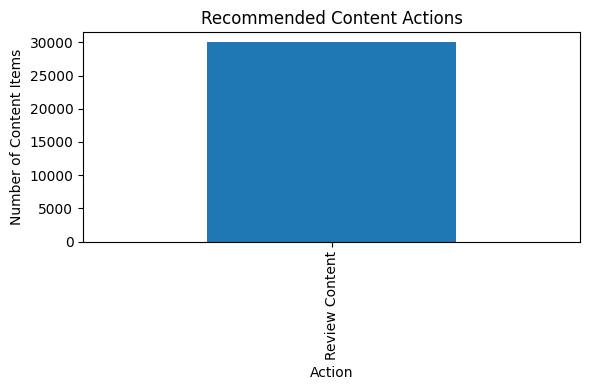

Figure saved: ../../work/figures\action_distribution.png


In [16]:
import os
import matplotlib.pyplot as plt

# Create figures folder if missing
figure_dir = "../../work/figures"

os.makedirs(
    figure_dir,
    exist_ok=True
)

# Count recommended actions
action_counts = (
    action_queue["recommended_action"]
    .value_counts()
)

plt.figure(figsize=(6,4))

action_counts.plot(
    kind="bar"
)

plt.title("Recommended Content Actions")
plt.xlabel("Action")
plt.ylabel("Number of Content Items")

plt.tight_layout()


figure_path = os.path.join(
    figure_dir,
    "action_distribution.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", figure_path)

In [17]:
import os

print(os.listdir("../../work/figures"))

['action_distribution.png']


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

## Self-check

Before submission:

[x] Ranked actions created with reason codes.

[x] Intended use and limitations documented.

[x] Human review rules explained.

[x] No-go automation cases listed.

[x] Monitoring and retraining triggers defined.

[x] Queue exported for the paper.

[x] Notebook runs successfully from top to bottom.